
# **Прогнозування з використанням часових рядів засобами Python**

Часовий ряд — це послідовність значень, впорядкованих за часовим інтервалом. Такі дані широко використовуються для аналізу змін показників та прогнозування майбутніх значень.

Основними складовими часових рядів є:

тренд — загальна тенденція зміни даних (зростання або спадання);
сезонність — періодичні повторення значень;
випадкові коливання — нерегулярні зміни.

Прогнозування часових рядів дозволяє оцінити майбутні значення на основі історичних даних.

**Моделі прогнозування**

Для прогнозування використовуються різні моделі. У даній роботі застосовується наївна модель прогнозування.

Наївна модель передбачає, що майбутнє значення дорівнює останньому відомому значенню часового ряду. Такий підхід є простим, але дозволяє отримати базовий прогноз.

Розглянемо приклад побудови прогнозу на основі масиву даних про пасажирів авіакомпаній.

# Встановлення та імпорт бібліотек

Спочатку встановлюється бібліотека sktime та імпортуються необхідні модулі для роботи



In [ ]:
!pip install sktime
from matplotlib import pyplot as plt
from sktime.datasets import load_airline
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.utils.plotting import plot_series
from sktime.forecasting.naive import NaiveForecaster

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 5.1 MB/s eta 0:00:00


# Завантаження даних

Далі виконується завантаження часового ряду:

In [ ]:
y = load_airline()

Ці дані містять інформацію про кількість пасажирів авіакомпаній за певний період часу.

# Розділення даних

Дані поділяються на тренувальну та тестову вибірки:

In [ ]:
y_train, y_test = temporal_train_test_split(y)

Тренувальна частина використовується для навчання моделі, а тестова — для перевірки прогнозу.

# Візуалізація початкових даних

Будується графік часового ряду:


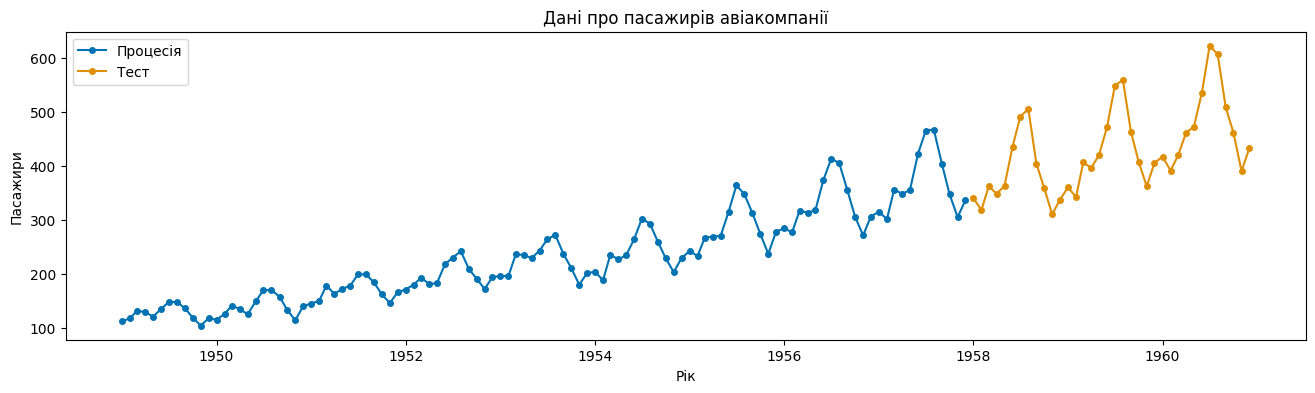

In [ ]:
plot_series(y_train, y_test, labels=["Процесія", "Тест"])
plt.title('Дані про пасажирів авіакомпанії')
plt.xlabel('Рік')
plt.ylabel('Пасажири')
plt.show()

Цей графік дозволяє побачити зміну кількості пасажирів у часі.

# Створення та навчання моделі

Створюється модель прогнозування та виконується її навчання:

In [ ]:
forecaster = NaiveForecaster(strategy="last")
forecaster.fit(y_train)

NaiveForecaster()

Модель використовує останнє значення для прогнозування майбутніх значень.

# Прогнозування

Задається горизонт прогнозування та обчислюються прогнозні значення:

In [ ]:
fh = list(range(1, 37))
y_pred = forecaster.predict(fh)

Прогноз виконується на 36 періодів уперед.

# Відображення прогнозу

Будується графік з прогнозом:

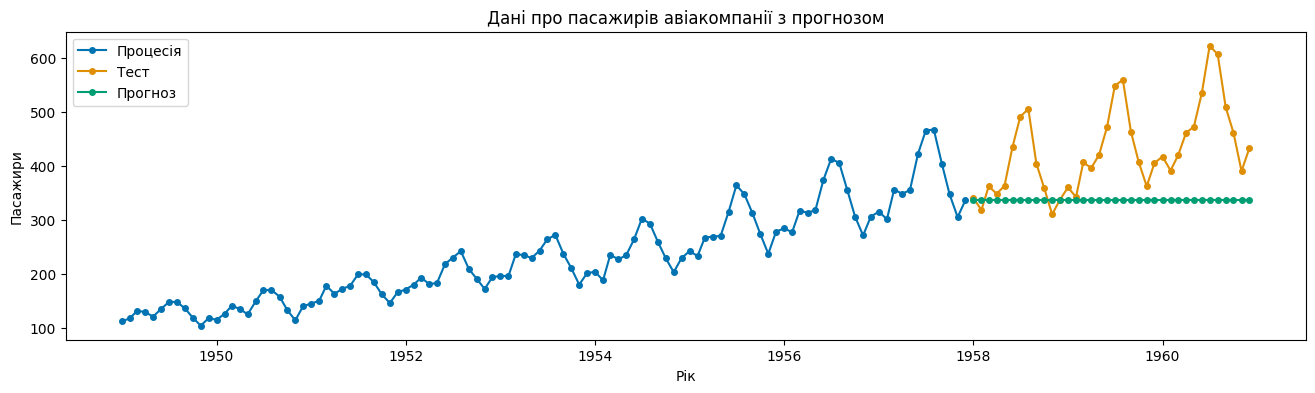

In [ ]:
plot_series(y_train, y_test, y_pred, labels=["Процесія", "Тест", "Прогноз"])
plt.title('Дані про пасажирів авіакомпанії з прогнозом')
plt.xlabel('Рік')
plt.ylabel('Пасажири')
plt.show()

На графіку відображаються початкові дані та прогнозовані значення.

Ми отримали  два графіки:

*   перший відображає розподіл тренувальних і тестових даних;
*   другий показує прогнозовані значення разом із реальними даними.

Це дозволяє оцінити поведінку часового ряду та якість прогнозування.





Таким чином, аналіз дозволив виявити основні характеристики часового ряду, зокрема наявність тренду та зміну значень у часі.

За допомогою бібліотеки sktime було реалізовано наївну модель прогнозування NaiveForecaster та отримано прогноз майбутніх значень. Оцінка точності здійснювалась шляхом порівняння прогнозованих і фактичних даних, що показало здатність моделі відтворювати загальну тенденцію розвитку процесу.

Використана модель має обмежену точність, оскільки не враховує можливі сезонні коливання та інші особливості часового ряду.
Таким чином, результати виконаної роботи підтверджують доцільність використання методів аналізу часових рядів для дослідження динаміки даних, а також свідчать про необхідність застосування більш складних моделей з метою підвищення точності прогнозування.
